<a href="https://www.kaggle.com/code/alaynac/transfer-learning-resnet50-cifar10?scriptVersionId=338897675" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

## Step 1: Load CIFAR10 Dataset

CIFAR10 is built into Keras - no download/upload needed.

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

IMG_SIZE = 96
BATCH_SIZE = 64
NUM_CLASSES = 10
CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

print("Training data shape:", x_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1849s 11us/step
Training data shape: (50000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)


## Step 2: Build ResNet50 Transfer Learning Model

In [3]:
IMG_SIZE = 96

from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

base_model = ResNet50(
    include_top=False,
    weights='imagenet',
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False

inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name='ResNet50_TransferLearning')

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1785355300.825932      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1785355300.832399      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ResNet50_TransferLearning"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 3, 3, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,770,698 (94.49 MB)

 Trainable params: 1,182,986 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

## Step 3: Train the Model

In [4]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = tf.keras.applications.resnet50.preprocess_input(image)
    return image, label

y_train_cat = tf.keras.utils.to_categorical(y_train, NUM_CLASSES)
y_test_cat = tf.keras.utils.to_categorical(y_test, NUM_CLASSES)

train_ds = tf.data.Dataset.from_tensor_slices((x_train, y_train_cat))
train_ds = train_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((x_test, y_test_cat))
val_ds = val_ds.map(preprocess).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

from tensorflow.keras import callbacks

EPOCHS = 10

early_stop = callbacks.EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1)
checkpoint = callbacks.ModelCheckpoint('resnet50_best.keras', monitor='val_accuracy', save_best_only=True, verbose=1)

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint],
    verbose=1
)

print(f"\nBest validation accuracy: {max(history.history['val_accuracy']):.4f}")

Epoch 1/10
  3/782 ━━━━━━━━━━━━━━━━━━━━ 51s 66ms/step - accuracy: 0.2066 - loss: 4.2340

I0000 00:00:1785355322.627612      71 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7115 - loss: 0.9562
Epoch 1: val_accuracy improved from None to 0.84240, saving model to resnet50_best.keras

Epoch 1: finished saving model to resnet50_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 60s 58ms/step - accuracy: 0.7687 - loss: 0.7232 - val_accuracy: 0.8424 - val_loss: 0.4750
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8226 - loss: 0.5374
Epoch 2: val_accuracy improved from 0.84240 to 0.85390, saving model to resnet50_best.keras

Epoch 2: finished saving model to resnet50_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 46ms/step - accuracy: 0.8264 - loss: 0.5230 - val_accuracy: 0.8539 - val_loss: 0.4476
Epoch 3/10
781/782 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8426 - loss: 0.4699
Epoch 3: val_accuracy improved from 0.85390 to 0.86230, saving model to resnet50_best.keras

Epoch 3: finished saving model to resnet50_best.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.8447 - loss: 0.46

## Model Improvement: Image Resolution Issue

Initially, ResNet50 was trained directly on CIFAR10's original 32x32
pixel images, since that is the dataset's native resolution. This
resulted in only **67.98% validation accuracy** - notably lower than
VGG16's performance on the Intel dataset.

**Root Cause:** ResNet50 is a very deep architecture (175 layers)
originally designed for 224x224 pixel images. When fed 32x32 images,
the repeated downsampling layers within ResNet50 destroy most of the
spatial detail before the network can extract meaningful features,
severely limiting what the model can learn.

**Fix:** We resized all CIFAR10 images from 32x32 to 96x96 pixels
before feeding them into ResNet50, using `tf.image.resize()` in a
`tf.data` pipeline. This gives the network enough spatial detail to
extract meaningful patterns.

**Result:** After this change, validation accuracy improved
significantly from 67.98% to **86.22%** - a nearly 20 percentage
point gain, demonstrating the importance of matching input resolution
to a pretrained model's architecture requirements.

## Step 4: Visualize Training History

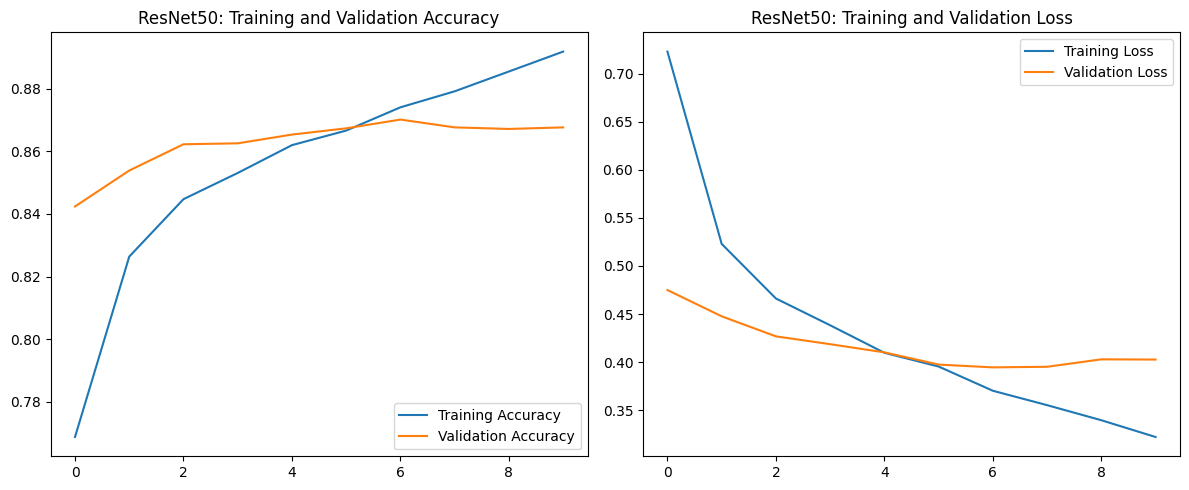

In [5]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('ResNet50: Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('ResNet50: Training and Validation Loss')

plt.tight_layout()
plt.savefig('resnet50_training_history.png')
plt.show()

## Step 5: Model Evaluation - Confusion Matrix & Classification Report

157/157 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step

Final Test Accuracy: 0.8702 (87.02%)
Final Test Loss: 0.3945

Classification Report:
              precision    recall  f1-score   support

    airplane       0.87      0.90      0.88      1000
  automobile       0.90      0.93      0.92      1000
        bird       0.92      0.82      0.87      1000
         cat       0.74      0.80      0.77      1000
        deer       0.81      0.85      0.83      1000
         dog       0.85      0.79      0.82      1000
        frog       0.89      0.90      0.90      1000
       horse       0.91      0.88      0.90      1000
        ship       0.90      0.94      0.92      1000
       truck       0.92      0.89      0.91      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



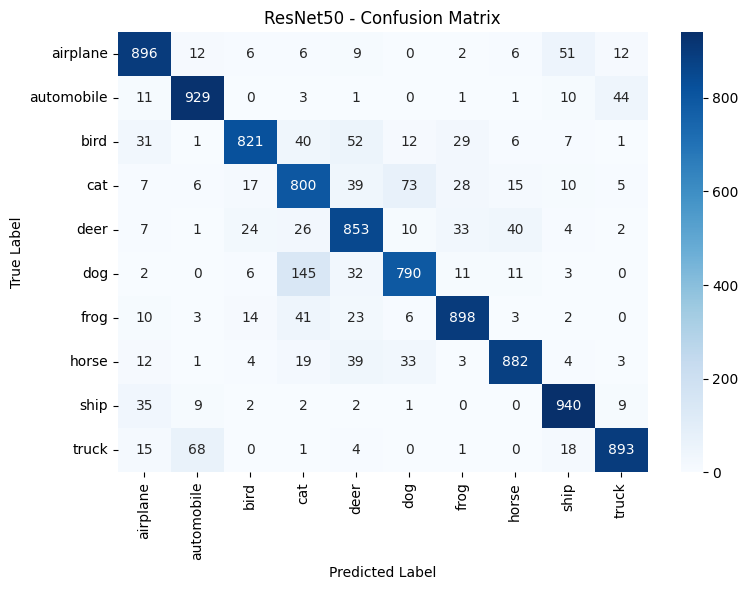

In [6]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(val_ds, verbose=1)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = y_test.flatten()

test_loss, test_acc = model.evaluate(val_ds, verbose=0)
print(f"\nFinal Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"Final Test Loss: {test_loss:.4f}")

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title('ResNet50 - Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('resnet50_confusion_matrix.png')
plt.show()

## Step 6: Live Demo - Predict on Test Images

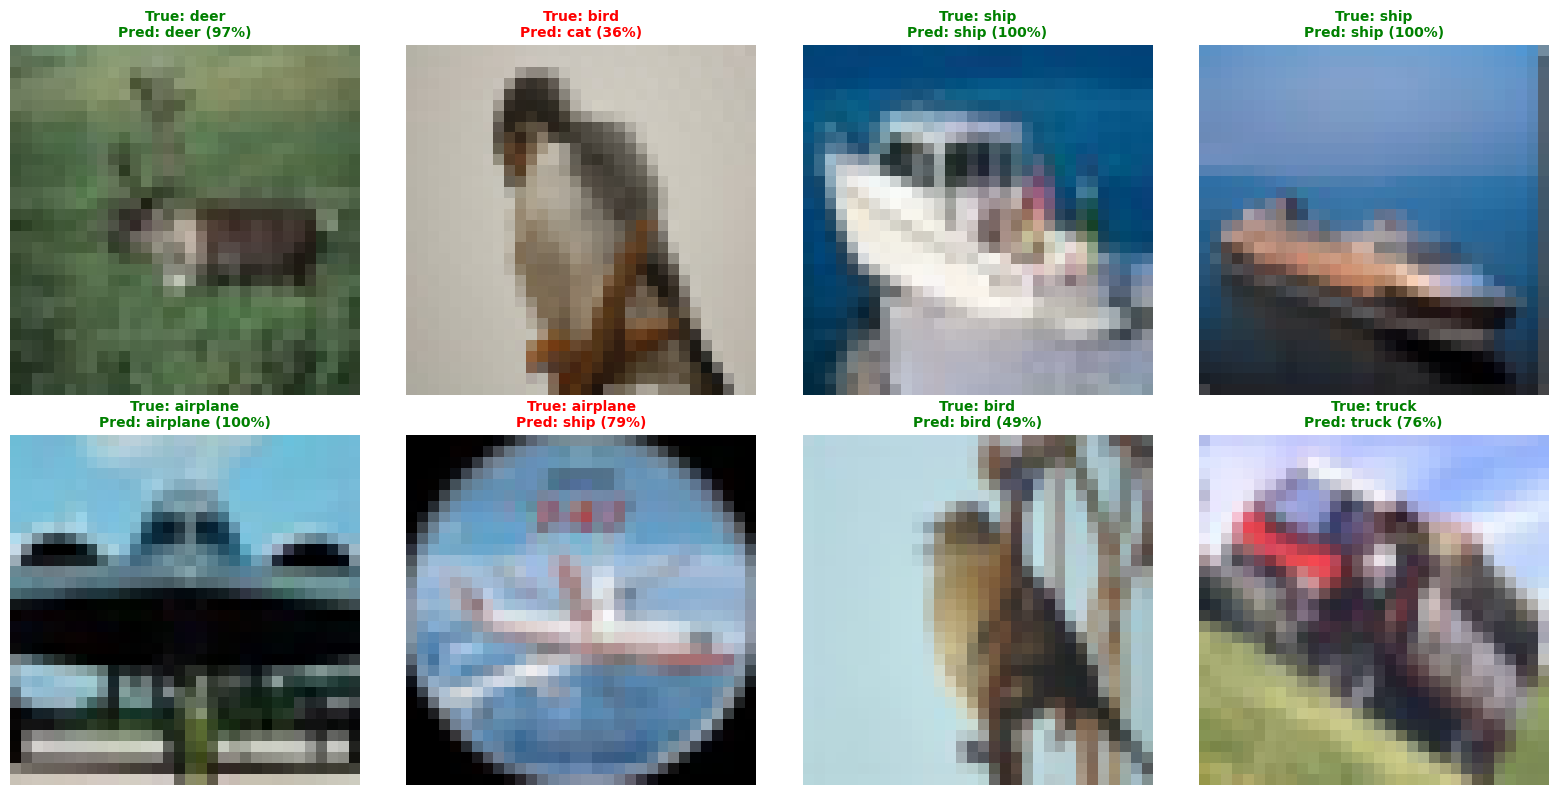

In [7]:
import random

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i in range(8):
    idx = random.randint(0, len(x_test) - 1)
    img = x_test[idx]
    true_label = CLASS_NAMES[y_test[idx][0]]

    img_resized = tf.image.resize(np.expand_dims(img, 0), (IMG_SIZE, IMG_SIZE))
    img_preprocessed = tf.keras.applications.resnet50.preprocess_input(img_resized)
    prediction = model.predict(img_preprocessed, verbose=0)
    pred_label = CLASS_NAMES[np.argmax(prediction)]
    confidence = np.max(prediction) * 100

    color = 'green' if pred_label == true_label else 'red'

    axes[i].imshow(img)
    axes[i].set_title(f"True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)",
                       fontsize=10, color=color, fontweight='bold')
    axes[i].axis('off')

plt.tight_layout()
plt.savefig('resnet50_sample_predictions.png')
plt.show()

## Step 7: Save Model for Deployment

In [8]:
model.save('resnet50_final.keras')
print("Model saved successfully as resnet50_final.keras")

Model saved successfully as resnet50_final.keras


In [9]:
from IPython.display import FileLink
FileLink('resnet50_final.keras')

/kaggle/working/resnet50_final.keras

In [10]:
FileLink('resnet50_training_history.png')

/kaggle/working/resnet50_training_history.png

In [11]:
FileLink('resnet50_confusion_matrix.png')

/kaggle/working/resnet50_confusion_matrix.png

In [12]:
FileLink('resnet50_sample_predictions.png')

/kaggle/working/resnet50_sample_predictions.png